# Advanced Econometrics – Lab 01

In [87]:
# !pip install numpy pandas statsmodels pandas stargazer
# packages
import math as math
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.stats.outliers_influence as smo

# working directory
import os as os
os.getcwd()
# os.chdir('C:/Users/Hp/WNE/Ekonometria/IiE/EKIiE_Z14_Python')
os.getcwd()

'/Users/ewaweychert/Desktop/econometrics/AE_Lab_01'

1 Undergraduate Econometrics
### Exercise 1
Let’s use the data file cps_small.csv that comes from the book Principles of Econome-
trics1.
We are interested in estimating an econometric model for logarithm of hourly wage
(lnWAGE ). 
List of regressors consists of:

* educ - years of education,
* female - dummy variable coding sex, 1 for women and 0 for men,
* black - dummy variable, 1 for blacks,
* femaleXblack - interaction between female and black.

Estimate the model and interpret the output.

In [9]:
# Exercise 1
# read the data
cps = pd.read_csv("cps_small.csv", sep=",")
print(cps)


          wage  educ  exper  female  black  white  midwest  south  west
0     2.030000    13      2       1      0      1        0      1     0
1     2.070000    12      7       0      0      1        1      0     0
2     2.120000    12     35       0      0      1        0      1     0
3     2.540000    16     20       1      0      1        0      1     0
4     2.680000    12     24       1      0      1        0      1     0
..         ...   ...    ...     ...    ...    ...      ...    ...   ...
995  35.419998    18     23       1      0      1        0      0     0
996  36.840000    16      7       1      0      1        1      0     0
997  41.320000    16     11       1      0      1        0      0     0
998  47.220001    18     35       0      0      1        0      0     0
999  60.189999    16     33       0      0      1        0      0     1

[1000 rows x 9 columns]


In [11]:
# generate lnWAGE
cps['lnWAGE'] = np.log(cps['wage'])
# generate the interaction term
cps['blackXfemale'] =cps['black']*cps['female']
cps

,wage,educ,exper,female,black,white,midwest,south,west,lnWAGE,blackXfemale
0,2.030000,13,2,1,0,1,0,1,0,0.708036,0
1,2.070000,12,7,0,0,1,1,0,0,0.727549,0
2,2.120000,12,35,0,0,1,0,1,0,0.751416,0
3,2.540000,16,20,1,0,1,0,1,0,0.932164,0
4,2.680000,12,24,1,0,1,0,1,0,0.985817,0
...,...,...,...,...,...,...,...,...,...,...,...
995,35.419998,18,23,1,0,1,0,0,0,3.567277,0
996,36.840000,16,7,1,0,1,1,0,0,3.606584,0
997,41.320000,16,11,1,0,1,0,0,0,3.721347,0
998,47.220001,18,35,0,0,1,0,0,0,3.854818,0


In [12]:
# model - version 1
reg = smf.ols(formula="lnWAGE~educ+female+black+blackXfemale", data=cps)
model1 = reg.fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 lnWAGE   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     93.37
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.88e-67
Time:                        12:24:43   Log-Likelihood:                -666.33
No. Observations:                1000   AIC:                             1343.
Df Residuals:                     995   BIC:                             1367.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.9566      0.084     11.361   

## Overview of the Model
This is an OLS regression where the dependent variable is log wages (lnWAGE).
* Number of observations: 1,000
* Number of predictors: 4
* R-squared: 0.273
* Adjusted R-squared: 0.270
This means the model explains about 27% of the variation in log wages, which is reasonable for cross-sectional wage data.
* The overall model is statistically significant:
F-statistic = 93.37
p-value < 0.001
So, taken together, the independent variables significantly explain wages.
Interpretation of the Coefficients
Because the dependent variable is in log form, coefficients can be interpreted approximately as percentage changes in wages.

1. Intercept (0.9566)
This is the predicted log wage for the baseline group:
Male
Non-black
With zero years of education (theoretical baseline)
It mainly serves as a reference point.

2. Education (educ = 0.1016) Significant
Highly statistically significant (p < 0.001).
Each additional year of education increases wages by about 10.2%, holding other variables constant.
This is a large and economically meaningful return to education.

3. Female (-0.2557) Significant
Highly significant (p < 0.001).
Being female is associated with approximately 25.6% lower wages, holding education and race constant.
Because the model is log-linear, this corresponds to roughly a 22–26% wage gap, depending on exact transformation.

4. Black (-0.1842) Significant
Statistically significant (p = 0.018).
Being Black is associated with about 18.4% lower wages, holding other variables constant.
This suggests a racial wage gap in the data.

5. Black × Female (0.0654) Not Significant
Not statistically significant (p = 0.537).
This means the additional effect of being both Black and female is not statistically different from zero.
In other words, there is no evidence in this model that the combined penalty differs from the sum of the individual effects.

## Model Diagnostics
* Durbin-Watson = 0.538 - This is low and may indicate positive autocorrelation (though in cross-sectional data this is often less concerning).

* Normality tests (Omnibus, Jarque-Bera) - p-values are high (> 0.4), suggesting residuals are approximately normally distributed.
<!-- Condition number = 113 -->
<!-- This is moderate and does not indicate severe multicollinearity. -->

## Overall Conclusion

* Education strongly increases wages.
* There is a statistically significant gender wage gap.
* There is a statistically significant racial wage gap.
* The interaction between race and gender is not statistically significant.
* The model explains about 27% of wage variation.

## Model Information Criteria

Your model reports:

- **AIC = 1343**
- **BIC = 1367**

## What They Mean

Both **AIC (Akaike Information Criterion)** and **BIC (Bayesian Information Criterion)** are measures used to compare models.

They balance:

- **Model fit** (how well the model explains the data)  
- **Model complexity** (how many parameters are included)

Both criteria penalize adding unnecessary variables.


## How to Interpret Them

- **Lower AIC is better**
- **Lower BIC is better**

They are only meaningful when comparing multiple models estimated on the same dataset.

By themselves, 1343 and 1367 do not tell us whether the model is “good” or “bad.”  
They are useful only if you compare this model to another one (for example, a model without the interaction term).


## Difference Between AIC and BIC

- **AIC** penalizes complexity moderately.
- **BIC** penalizes complexity more strongly (especially in large samples like *n = 1000*).

Because your sample is fairly large, **BIC will be stricter** about adding unnecessary variables.

## What This Means for Your Model

Since the interaction term (`blackXfemale`) is statistically insignificant, you might:

1. Estimate a model without the interaction  
2. Compare AIC and BIC  
3. If AIC and BIC decrease → the simpler model is preferred  


## Short Academic Sentence You Can Use

The model’s AIC (1343) and BIC (1367) provide information criteria for model comparison; lower values would indicate a preferred specification when comparing alternative models.


In [ ]:
# model - version 2
reg = smf.ols(formula="np.log(wage)~educ+female+black+black*female", data=cps)
model2 = reg.fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:           np.log(wage)   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     93.37
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.88e-67
Time:                        12:30:16   Log-Likelihood:                -666.33
No. Observations:                1000   AIC:                             1343.
Df Residuals:                     995   BIC:                             1367.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.9566      0.084     11.361   

In [14]:
# model - version 3
reg = smf.ols(formula="np.log(wage)~educ+female+black+black:female", data=cps)
model3 = reg.fit()
print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:           np.log(wage)   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     93.37
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.88e-67
Time:                        12:30:27   Log-Likelihood:                -666.33
No. Observations:                1000   AIC:                             1343.
Df Residuals:                     995   BIC:                             1367.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.9566      0.084     11.361   

from IPython.display import display, HTML

html_table = """
<table border="1" cellpadding="6" cellspacing="0">
  <thead>
    <tr>
      <th>Model</th>
      <th>Log specification</th>
      <th>Interaction handling</th>
      <th>Same as others?</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>Model 1</b></td>
      <td>Uses <code>lnWAGE</code> variable</td>
      <td>Manual interaction</td>
      <td>Same if <code>lnWAGE = log(wage)</code></td>
    </tr>
    <tr>
      <td><b>Model 2</b></td>
      <td>Uses <code>np.log(wage)</code></td>
      <td>Automatic (<code>*</code>)</td>
      <td>Same as Model 3</td>
    </tr>
    <tr>
      <td><b>Model 3</b></td>
      <td>Uses <code>np.log(wage)</code></td>
      <td>Explicit (<code>:</code>)</td>
      <td>Same as Model 2</td>
    </tr>
  </tbody>
</table>
"""

display(HTML(html_table))


In [ ]:
# Quality Publication Table
# !pip install stargazer
from stargazer.stargazer import Stargazer

s = Stargazer([model1, model2, model3])
from IPython.core.display import HTML
a = HTML(s.render_html())
html = a.data
with open("html_file_Exercise1.html", "w") as f:
    f.write(html)

a

## Exercise 2
Use data on houses sold in Stockton, California, to estimate a model for logarithm of price
(lnPRICE ). As regressors use:
total square feet of living area (sqft), 
* number of full baths (baths), 
* info on whether it is vacant Yes = 1 No = 0 (vacant), 
* whether it has two floors (stories2 ), 
* vac_sto2 that is interaction term between vacant and stories2.

a. Estimate the model:

lnPRICE= β0 + β1sqft+ β2baths+ β3vacant+ β4stories2 + ε

b. Estimate the model:

lnPRICE= β0 + β1sqft+ β2sqft2 + β3baths+ β4vacant+ + β5stories2 + β6vacant× stories2 + ε

In [20]:
# Exercise 2
stockton = pd.read_csv("stockton2.csv", sep=",")
print(stockton)


      price  sqft  beds  baths  age  stories  vacant
0    205000  2377     4      3    0        2       1
1    230000  2325     4      3    0        2       1
2    117000  1651     3      2    9        2       1
3     80000  1213     3      1   63        1       0
4    116500  1800     4      2   17        1       0
..      ...   ...   ...    ...  ...      ...     ...
875  168000  2120     4      3    7        2       1
876  135000  1714     4      3    3        2       1
877  115000  1501     3      2   11        1       1
878  112000  1367     3      2   16        1       1
879   90300   976     2      2   15        1       1

[880 rows x 7 columns]


In [21]:
# model 1
reg = smf.ols(formula="np.log(price)~sqft+baths+vacant+stories", data=stockton)
model1 = reg.fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     565.7
Date:                Thu, 19 Feb 2026   Prob (F-statistic):          7.31e-241
Time:                        12:37:15   Log-Likelihood:                 173.51
No. Observations:                 880   AIC:                            -337.0
Df Residuals:                     875   BIC:                            -313.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.6598      0.026    411.965      0.0

In [22]:
# model 2
reg = smf.ols(formula="np.log(price)~sqft+sqft^2+baths+vacant+stories+vacant:stories", 
              data=stockton)
model2 = reg.fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     376.8
Date:                Thu, 19 Feb 2026   Prob (F-statistic):          2.62e-238
Time:                        12:37:20   Log-Likelihood:                 173.98
No. Observations:                 880   AIC:                            -334.0
Df Residuals:                     873   BIC:                            -300.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         10.6789      0.033    325.

## Exercise 3
Use data on houses sold in Stockton, California, to estimate a model for logarithm of
price (lnPRICE ).

* number of full baths (baths), 
* info on whether it is vacant Yes = 1 No = 0 (vacant), 
* whether it has two floors (stories2 ), 
* vac_sto2 that is interaction term between vacant and stories2.

Let’s reconsider the model from Exercise 2 (a). Verify assumptions of the linear regression
model for the model lnPRICE= β0 + β1sqft+ β2baths+ ε.

a. Verify the functional form of the model.
* Ramsey’s RESET test

b. Check the assumption of homoscedasticity
* Breusch’s and Pagan’s test
* White’s test

c. Is the error term normally distributed?

In [27]:
# a. Verify the functional form of the model.
# We want to check whether the assumed linear specification:
#     price = β0 + β1*age + β2*sqft + u
# is correctly specified.
#
# In particular, we test whether we have omitted important nonlinear terms
# (e.g., squares, cubes, interactions).
#
# We use Ramsey’s RESET test for this purpose.

import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.stats.outliers_influence as smo


def interpret_reset(reset_result, alpha=0.05, label="Model"):
    """
    Prints a simple interpretation of Ramsey RESET test output.

    RESET null hypothesis (H0): functional form is correctly specified
    (no omitted nonlinear terms / interactions in the conditional mean).

    If p-value <= alpha -> reject H0 -> evidence of misspecification.
    If p-value > alpha  -> fail to reject H0 -> no evidence of misspecification.

    IMPORTANT:
    - RESET is a general specification test. A rejection does NOT tell you
      which variable/term is missing, only that something nonlinear might be.
    - Passing RESET does NOT prove the model is correct; it only means
      we did not detect misspecification with this test.
    """
    pval = reset_result.pvalue
    stat = reset_result.statistic

    print("\n" + "="*70)
    print(f"Ramsey RESET interpretation — {label}")
    print("="*70)
    print(f"Test statistic: {stat:.4f}")
    print(f"p-value       : {pval:.6f}")
    print(f"Significance α: {alpha}")

    if pval <= alpha:
        print("\nConclusion: Reject H0.")
        print("Interpretation:")
        print("- There is evidence that the functional form may be misspecified.")
        print("- The model may be missing nonlinear terms (squares/cubes),")
        print("  interactions, or other transformations.")
        print("\nWhat to do next:")
        print("- Try adding plausible nonlinear terms (e.g., age^2, age^3),")
        print("  interactions (age*sqft), or log transformations, then re-test.")
        print("- Also check residual plots and domain theory for guidance.")
    else:
        print("\nConclusion: Fail to reject H0.")
        print("Interpretation:")
        print("- No evidence (at this α) that the functional form is misspecified.")
        print("- The linear specification may be adequate for the conditional mean.")
        print("\nCaution:")
        print("- This does NOT prove the model is correct; it only says RESET")
        print("  did not detect misspecification.")
    print("="*70 + "\n")


In [29]:
# 1. Load the data
# The dataset contains housing prices and characteristics.
# We import it directly from the URL (Stata format).
data = pd.read_stata("http://www.principlesofeconometrics.com/poe3/data/stata/stockton.dta")

# 2. Estimate the baseline (linear) model
# Functional form assumed:
# price = β0 + β1*age + β2*sqft + u
#
# This assumes:
# - linear relationship in age
# - linear relationship in sqft
# - no interaction effects
# - no nonlinearities
reg = smf.ols(formula="np.log(price) ~ age + sqft", data=data)
model = reg.fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     2915.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:02:15   Log-Likelihood:                 410.11
No. Observations:                4682   AIC:                            -814.2
Df Residuals:                    4679   BIC:                            -794.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.6480      0.016    661.037      0.0

In [ ]:
# Interpretation of baseline model:
#
# - Coefficients: show marginal effects (ceteris paribus).
#   Example:
#   * β_age: expected change in price for a 1-unit increase in age,
#            holding sqft constant.
#   * β_sqft: expected change in price for +1 sqft, holding age constant.
#
# - p-values: indicate whether each coefficient is statistically different from 0.
# - R^2: share of variation in price explained by included regressors (descriptive).
# - F-test (Prob(F-statistic)): whether regressors are jointly significant.
#
# But even if coefficients look significant, the functional form might still be wrong.
# That is why we run RESET.

# When to Use It
# You use RESET when you want to check:
# Did I forget important variables?
# Should I include nonlinear terms?
# Is my functional form correct?

In [38]:
# a) functional form validity
# i. Ramsey's RESET test
resettest = smo.reset_ramsey(
    res=model, # “Run the RESET test on this estimated regression.”
    degree=3  # With degree=3, the test adds: squared fitted values (ŷ²) cubed fitted values (ŷ³)
    #  If ŷ² or ŷ³ matter → something nonlinear is missing.
    )
print(resettest.summary())

<F test: F=33.614396438114, p=3.2016998646479586e-15, df_denom=4.68e+03, df_num=2>


### Interpretation of Ramsey’s RESET test
### Hypotheses
* H₀: The functional form is correctly specified
(no omitted nonlinear terms, no missing transformations)
* H₁: The model is misspecified
(important nonlinearities or interactions are omitted)
* The p-value is:
* p = 3.20×10−15

This is far below 0.05 (and even 0.01).
Therefore: We reject H₀ at any conventional significance level.


### Economic Interpretation

There is **strong statistical evidence** that the linear specification:

price = β0 + β1*age + β2*sqft + u

is **misspecified**.

This means:

- The relationship between **price** and **age** and/or **sqft** is **not purely linear**.
- The model likely omits:
  - nonlinear terms (e.g., \( age^2 \), \( age^3 \))
  - interaction effects (e.g., \( age \times sqft \))
  - other functional transformations (e.g., logarithms)

###  What Does This Mean Practically?

The linear model:

- May produce **biased inference** about the shape of the relationship  
- May give **misleading marginal effects**  
- May incorrectly estimate **standard errors**  
- May produce **inferior predictions**

### What Should Be Done Next?

✔ Try adding:

- polynomial terms (e.g., \( age^2 \), \( age^3 \))  
- interaction terms (e.g., \( age \times sqft \))  
- log transformations (e.g., \( \log(price) \), \( \log(sqft) \))

✔ Re-estimate the model  

✔ Re-run the RESET test  

✔ Compare:
- Adjusted \( R^2 \)  
- AIC / BIC  
- Economic interpretability  


###  Very Important Teaching Remark

The RESET test **does NOT tell us what exactly is wrong**.

It only indicates that:

> *"Something nonlinear is missing."*

It does **not** identify:

- which variable,
- which power,
- or which transformation is needed.

Economic theory, subject-matter knowledge, and residual diagnostics should guide the correction of the model.


## RESET follow-up: correcting the functional form

Because the RESET test strongly rejected the linear specification, we try to **enrich the model** by adding nonlinearities and an interaction.

### Step 1 — Expanded (“regressor”) specification

We estimate a flexible version of the model by adding:

- polynomial terms: age^2, age^3, sqft^2, sqft^3

Economic meaning:
The depreciation of a house may accelerate or slow down over time.
Very new houses may lose value quickly.
Older houses may stabilize.
Very old houses may even increase in value (historical charm).


- interaction term: age*sqft

Economic meaning:
Extra square footage may be more valuable in new houses.
Or extra square footage may matter less in very old properties.
Buyers may value space differently depending on condition.


price = β0 + β1*age + β2*sqft + β3*age^2 + β4*sqft^2 + β5*age^3 + β6*sqft^3 + β7*(age*sqft) + u


**Interpretation:**  
This specification allows:
- the marginal effect of **age** on price to vary with age (nonlinear depreciation pattern),
- the marginal effect of **sqft** to vary with size (nonlinear size premium),
- the effect of **sqft** to depend on **age** (interaction).

However, this model can be **over-parameterized** and may produce multicollinearity, so we typically simplify it based on statistical significance and interpretability.


In [41]:
# 3. Ramsey RESET test (functional form validity)
# RESET = Regression Specification Error Test
#
# Idea:
# If the model is correctly specified, adding powers of fitted values
# (ŷ², ŷ³, etc.) should NOT significantly improve the model.
#
# H0: Model is correctly specified (no omitted nonlinear terms)
# H1: Model is misspecified (missing nonlinearities or interactions)

reg = smf.ols(formula="np.log(price) ~ age + sqft", data=data)
model = reg.fit()

# print(model.summary())

resettest = smo.reset_ramsey(res=model, degree=3)
# print(resettest.summary())


# INTERPRETATION (RESET for baseline):
interpret_reset(resettest, alpha=0.05, label="Baseline linear model: price ~ age + sqft")



Ramsey RESET interpretation — Baseline linear model: price ~ age + sqft
Test statistic: 33.6144
p-value       : 0.000000
Significance α: 0.05

Conclusion: Reject H0.
Interpretation:
- There is evidence that the functional form may be misspecified.
- The model may be missing nonlinear terms (squares/cubes),
  interactions, or other transformations.

What to do next:
- Try adding plausible nonlinear terms (e.g., age^2, age^3),
  interactions (age*sqft), or log transformations, then re-test.
- Also check residual plots and domain theory for guidance.



Typical lecture-ready interpretation sentence templates:
- If p-value < 0.05:
  "We reject the null of correct functional form; the linear model likely omits
   nonlinearities or interactions. We should consider adding polynomial terms
   or interactions and re-testing."
- If p-value >= 0.05:
  "We do not find evidence of functional form misspecification; the linear form
   may be adequate for the conditional mean, though this is not a proof."

In [ ]:
# 4. Manually extend the model with nonlinear terms

# If RESET suggests misspecification, try plausible expansions:
# - squared terms
# - cubic terms
# - interaction terms
#
# I(age**2) : include age squared
# I(sqft**2): include sqft squared
# age:sqft  : interaction between age and sqft (effect of sqft depends on age, etc.)

reg = smf.ols(
    formula="price ~ age + sqft + I(age**2) + I(sqft**2) + I(age**3) + I(sqft**3) + age:sqft",
    data=data
)
reset_regressor = reg.fit()

print(reset_regressor.summary())

# Interpretation of expanded model:
#
# - Polynomial terms allow marginal effects to vary with the level of the variable.
#   Example with age:
#   price = ... + β1*age + β2*age^2 + β3*age^3 + ...
#   Then the marginal effect of age is not constant:
#   ∂E(price)/∂age = β1 + 2β2*age + 3β3*age^2
#
# - Interaction term age:sqft implies the effect of sqft depends on age:
#   ∂E(price)/∂sqft = β_sqft + β_interaction*age
#   So bigger houses may add more/less value depending on how old the property is.
#
# Practical caveat for students:
# - Higher-order polynomials can fit noise and inflate standard errors (collinearity).
# - Prefer theory + parsimony; keep only terms that are meaningful and helpful.

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     819.6
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:22:14   Log-Likelihood:                -53811.
No. Observations:                4682   AIC:                         1.076e+05
Df Residuals:                    4674   BIC:                         1.077e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     5158.9324      2e+04      0.259   

## Interpretation:
* The linear age term is not significant.
* But age² and age³ are significant.
This means:
The relationship between age and price is nonlinear and curved, not a straight line.
So price does not decrease (or increase) at a constant rate with age — the effect changes depending on how old the house is.

## What This Means Economically

Your RESET test likely suggested misspecification. Now we see:
* There is strong evidence of nonlinear effects for age
* There is an important interaction between age and size
* There is little evidence for nonlinear effects in sqft

So a cleaner improved model could be:

price ~ age + I(age**2) + I(age**3) + sqft + age:sqft

And probably drop:
* I(sqft**2)
* I(sqft**3)

In [46]:
# (Optional but useful) Check RESET again for the expanded model:
reset_expanded = smo.reset_ramsey(res=reset_regressor, degree=3)
# print(reset_expanded.summary())
interpret_reset(reset_expanded, alpha=0.05, label="Expanded model (many polynomial terms + interaction)")


Ramsey RESET interpretation — Expanded model (many polynomial terms + interaction)
Test statistic: 1.3651
p-value       : 0.255446
Significance α: 0.05

Conclusion: Fail to reject H0.
Interpretation:
- No evidence (at this α) that the functional form is misspecified.
- The linear specification may be adequate for the conditional mean.

Caution:
- This does NOT prove the model is correct; it only says RESET
  did not detect misspecification.



In [47]:
# 5. Build a corrected (more parsimonious) model
# After inspecting significance + interpretability, remove unhelpful terms.
# Example: keep nonlinear age terms + interaction, drop sqft^2 and sqft^3.

reg = smf.ols(
    formula="price ~ age + sqft + I(age**2) + I(age**3) + age:sqft",
    data=data
)
model2 = reg.fit()
# print(model2.summary())

reset2 = smo.reset_ramsey(res=model2, degree=3)

interpret_reset(reset2, alpha=0.05, label="Corrected (parsimonious) model")


Ramsey RESET interpretation — Corrected (parsimonious) model
Test statistic: 2.8083
p-value       : 0.060410
Significance α: 0.05

Conclusion: Fail to reject H0.
Interpretation:
- No evidence (at this α) that the functional form is misspecified.
- The linear specification may be adequate for the conditional mean.

Caution:
- This does NOT prove the model is correct; it only says RESET
  did not detect misspecification.



# Exercise 3 — Homoscedasticity & Heteroskedasticity

## Model Setup

We use data on houses sold in **Stockton, California** to estimate a model for:

**ln(PRICE)**

### Variables:
- `baths` → number of full bathrooms  
- `vacant` → 1 if vacant, 0 otherwise  
- `stories2` → 1 if two floors  
- `vac_sto2` → interaction between vacant and stories2  

We reconsider the model from Exercise 2(a):

ln(PRICE) = β0 + β1*sqft + β2*age + + u


# Part (b): Check Homoscedasticity

## What is Homoscedasticity?

The variance of the errors must be constant:

\[
Var(u_i \mid X) = \sigma^2
\]

If this assumption fails → we have **heteroskedasticity**.


# What is Heteroskedasticity?

It means:

> The spread of the mistakes (errors) is not constant.

### Simple Example (House Prices)

- Small houses → prices vary by ± $5,000  
- Large luxury houses → prices vary by ± $100,000  

So the variance grows with house size.

That is heteroskedasticity.


# Dartboard Metaphor

### Homoscedasticity (Good Case)

- Everyone’s darts are equally spread around the center.
- The spread looks the same everywhere.
- Uncertainty is constant.

### Heteroskedasticity (Problem Case)

- Beginners throw wildly.
- Experts throw tightly grouped darts.
- The spread differs across people.

Unequal spread = unequal variance.


# Why Is It Important?

Heteroskedasticity:

- Does NOT bias your coefficients  
- DOES bias your standard errors  

That means:
- t-tests can be wrong  
- p-values can be wrong  
- You may think something is significant when it is not  
- Or miss something that is significant  

# Simple Memory Rule

**Heteroskedasticity = Unequal noise**

- Equal noise → safe inference  
- Unequal noise → unreliable inference  

# Why Does It Happen?

It often occurs when:

- The dependent variable grows in magnitude  
- The scale of measurement increases  
- Omitted variables matter more for large observations  
- The model is misspecified  
- The data are cross-sectional  

Cross-sectional data (people, firms, houses) naturally have different sizes and risks, so variance often differs.


# OLS Assumption

OLS assumes:

\[
Var(u_i \mid X) = \sigma^2
\]

But in reality we often have --> HOMOSECDASITSITY

\[
Var(u_i \mid X) = \sigma^2 X_i
\]

Meaning the variance depends on X.

That is heteroskedasticity.

# Breusch–Pagan Test

## Hypotheses

\[
H_0: \text{Homoscedasticity}
\]

\[
H_1: \text{Heteroskedasticity}
\]

### Decision Rule

- If p-value > 0.05 → Do not reject \(H_0\) (good)  
- If p-value < 0.05 → Reject \(H_0\) (heteroskedasticity present)  


# White’s Test

White’s test checks for:

- General heteroskedasticity  
- Nonlinear forms of heteroskedasticity  

Decision rule is the same:

- p-value > 0.05 → Homoscedasticity  
- p-value < 0.05 → Heteroskedasticity  


# Final Takeaway

Heteroskedasticity is very common in cross-sectional data.

It does not affect coefficient estimates,  
but it makes inference unreliable.

If detected → use **robust standard errors**.


## Breusch–Pagan
“Can the size of the errors be explained by the regressors?”
If YES → heteroskedasticity.
If NO → constant variance.

### Example (Housing)
Suppose:
Larger houses → larger pricing errors
Smaller houses → smaller errors

Then squared residuals increase with sqft.
The auxiliary regression will detect this relationship.
So the test rejects homoscedasticity.

### Steps:
Square the residuals.
Regress them on X.
If X explains squared residuals → heteroskedasticity.


**Step 1. Estimate your regression**

y=Xβ+u
You get residuals: u^i​

**Step 2 Square the residuals**
Why square them?
Because variance is based on squared errors. u^i2​

 If the variance is constant, these squared residuals should NOT depend on X.


**Step 3 Run an auxiliary regression**
Breusch–Pagan regresses:

 u^i2​onX
​	
 u^i2​=α0​+α1​X1​+α2​X2​+⋯+vi​


It tests:

H0​:α1​=α2​=⋯=0

Meaning:
Squared residuals do NOT depend on X
→ variance is constant
→ homoscedasticity

H1​:At least one αj​!=0


Meaning:
Variance depends on X
→ heteroskedasticity

In [ ]:
# Step 1 — Estimate the Model
reg = smf.ols(formula="price ~ age + sqft", data=data)
model = reg.fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.544
Method:                 Least Squares   F-statistic:                     2796.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:28:54   Log-Likelihood:                -53846.
No. Observations:                4682   AIC:                         1.077e+05
Df Residuals:                    4679   BIC:                         1.077e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.008e+04   1736.638      5.807      0.0

In [ ]:
from statsmodels.compat import lzip
import statsmodels.stats.api as sms

names = ['Lagrange multiplier statistic', 'p-value',
         'f-value', 'f p-value']

test_result = sms.het_breuschpagan(model.resid, model.model.exog)
lzip(names, test_result)

# How to Interpret
# If p-value > 0.05 → no heteroskedasticity (good)
# If p-value < 0.05 → heteroskedasticity present (bad)


[('Lagrange multiplier statistic', np.float64(187.5054019585027)),
 ('p-value', np.float64(1.921849173040554e-41)),
 ('f-value', np.float64(97.6013828280201)),
 ('f p-value', np.float64(2.9689048654447264e-42))]

LM statistic = 187.51

p-value = 1.92 × 10⁻⁴¹

F-statistic = 97.60

F p-value = 2.97 × 10⁻⁴²

## What Do We Look At?
The most important number is the p-value.

Your p-value: 1.92×10−41

That is basically zero.

There is strong evidence of heteroskedasticity in your model.

In [51]:
import statsmodels.stats.api as sms
import numpy as np

def breusch_pagan_test(model, alpha=0.05):
    """
    Runs Breusch–Pagan test for heteroskedasticity
    and prints interpretation automatically.
    
    Parameters
    ----------
    model : fitted statsmodels regression result
    alpha : significance level (default = 0.05)
    """
    
    # Run test
    lm_stat, lm_pvalue, f_stat, f_pvalue = sms.het_breuschpagan(
        model.resid, model.model.exog
    )
    
    # Pretty formatting
    def fmt(x):
        x = float(x)
        if abs(x) < 1e-4 or abs(x) > 1e4:
            return f"{x:.3e}"
        return f"{x:.4f}"
    
    print("=== Breusch–Pagan Test ===")
    print(f"LM statistic  : {fmt(lm_stat)}")
    print(f"LM p-value    : {fmt(lm_pvalue)}")
    print(f"F statistic   : {fmt(f_stat)}")
    print(f"F p-value     : {fmt(f_pvalue)}")
    
    print("\nDecision:")
    
    if lm_pvalue < alpha:
        print(f"Reject H0 at α = {alpha}")
        print("→ Evidence of heteroskedasticity.")
        print("→ Use robust standard errors (e.g., cov_type='HC3').")
    else:
        print(f"Fail to reject H0 at α = {alpha}")
        print("→ No evidence of heteroskedasticity.")



# Step 1 — Estimate the Model
reg = smf.ols(formula="price ~ age + sqft", data=data)
model = reg.fit()
# print(model.summary())

breusch_pagan_test(model, alpha=0.05)

=== Breusch–Pagan Test ===
LM statistic  : 187.5054
LM p-value    : 1.922e-41
F statistic   : 97.6014
F p-value     : 2.969e-42

Decision:
Reject H0 at α = 0.05
→ Evidence of heteroskedasticity.
→ Use robust standard errors (e.g., cov_type='HC3').


#### What Is White’s Test?

White’s test checks whether your regression has **heteroskedasticity**.

In simple words:

> Do the errors have constant variance?


#### What Problem Is It Solving?

OLS assumes:

\[
\operatorname{Var}(u_i \mid X_i) = \sigma^2
\]

This means:

- The spread of the errors is the same for all observations.

If this is false → we have **heteroskedasticity**.

White’s test checks whether this assumption is violated.


#### How Does White’s Test Work?

### Step 1. Estimate your main regression

\[
y = X\beta + u
\]

Get residuals:

\[
\hat{u}_i
\]


### Step 2. Square the residuals

\[
\hat{u}_i^2
\]

Why?  
Because variance is based on **squared errors**.


### Step 3. Run an auxiliary regression

White regresses:

\[
\hat{u}_i^2
\]

on:

- All original regressors  
- Their squares  
- Their cross-products (interactions)  

## Example

If your original model is:

\[
y = \beta_0 + \beta_1 age + \beta_2 sqft
\]

White runs:

\[
\hat{u}_i^2 =
\alpha_0 +
\alpha_1 age +
\alpha_2 sqft +
\alpha_3 age^2 +
\alpha_4 sqft^2 +
\alpha_5 (age \cdot sqft) +
v_i
\]


####  What Is It Testing?

\[
H_0: \text{Homoscedasticity}
\]

\[
H_1: \text{Heteroskedasticity}
\]

More precisely:

\[
H_0: \alpha_1 = \alpha_2 = \alpha_3 = \dots = 0
\]

Meaning:

- The regressors **do NOT explain** the squared residuals  
- The variance does NOT depend on X  

If they do → variance depends on X → heteroskedasticity.

---

#### Test Statistic

White uses:

\[
LM = n \cdot R^2
\]

where:

- \( n \) = number of observations  
- \( R^2 \) = from the auxiliary regression  

Under \(H_0\), the statistic follows a Chi-square distribution.

---

#### Why White Is More Flexible Than Breusch–Pagan

**Breusch–Pagan:**
- Tests only linear relationship between variance and X.

**White:**
- Allows nonlinear patterns.
- Includes squares and interactions.
- Detects more general forms of heteroskedasticity.

So White is more robust.

#### Simple Housing Example

Imagine:

- Variance increases with house size.
- But not linearly.
- Maybe variance grows much faster for luxury homes.

Breusch–Pagan might miss this.

White will catch it.


#### Important Result

White test:

- Does NOT change coefficient estimates.
- DOES affect standard errors.

If it rejects → use **robust standard errors**.


White test asks:

> “Can the regressors, their squares, or their interactions explain the size of the errors?”

If yes → heteroskedasticity.


# Breusch–Pagan vs White Test

| Feature | Breusch–Pagan Test | White Test |
|----------|-------------------|------------|
| Purpose | Test for heteroskedasticity | Test for heteroskedasticity |
| Null Hypothesis | Homoscedasticity | Homoscedasticity |
| Alternative Hypothesis | Heteroskedasticity | Heteroskedasticity |
| What is regressed? | Squared residuals on original regressors | Squared residuals on regressors, their squares, and interactions |
| Detects | Linear form of heteroskedasticity | General (linear & nonlinear) heteroskedasticity |
| Flexibility | Less flexible | More flexible |
| Requires manual nonlinear terms? | No | No (automatically includes them) |
| Test statistic | \( LM = n \cdot R^2 \) | \( LM = n \cdot R^2 \) |
| Distribution under \(H_0\) | Chi-square | Chi-square |
| Power in large samples | Good | Very good |
| Risk | May miss nonlinear variance patterns | May over-reject in very large samples |


In [54]:
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

# ----------------------------------------------------
# Step 1 — Estimate the regression model
# ----------------------------------------------------
# price = β0 + β1*age + β2*sqft + u
reg = smf.ols(formula="price ~ age + sqft", data=data)
model = reg.fit()

# ----------------------------------------------------
# Step 2 — Run White's test for heteroskedasticity
# ----------------------------------------------------
# White test checks:
# H0: Homoscedasticity (constant variance)
# H1: Heteroskedasticity

white_test = sms.het_white(model.resid, model.model.exog)

# Extract results
white_stat, white_pval, f_stat, f_pval = white_test

print("=== White Test ===")
print(f"LM statistic  : {white_stat}")
print(f"LM p-value    : {white_pval}")
print(f"F statistic   : {f_stat}")
print(f"F p-value     : {f_pval}")


# p<0.05  We reject H0
# There is very strong evidence of heteroskedasticity.


=== White Test ===
LM statistic  : 229.0912008028593
LM p-value    : 1.674880798821197e-47
F statistic   : 48.1137388283054
F p-value     : 1.0723007133992029e-48


In [55]:
def white_test_interpretation(model, alpha=0.05):
    """
    Runs White's test for heteroskedasticity
    and prints interpretation automatically.
    """
    
    import statsmodels.stats.api as sms
    
    # Run White test
    white_stat, white_pval, f_stat, f_pval = sms.het_white(
        model.resid, model.model.exog
    )
    
    # Formatting helper
    def fmt(x):
        if abs(x) < 1e-4:
            return f"{x:.3e}"
        return f"{x:.4f}"
    
    print("=== White Test for Heteroskedasticity ===")
    print(f"LM statistic  : {fmt(white_stat)}")
    print(f"LM p-value    : {fmt(white_pval)}")
    print(f"F statistic   : {fmt(f_stat)}")
    print(f"F p-value     : {fmt(f_pval)}")
    
    print("\nDecision:")
    
    if white_pval < alpha:
        print(f"Reject H0 at α = {alpha}")
        print("→ Evidence of heteroskedasticity.")
        print("→ Recommendation: Use robust standard errors (HC3).")
    else:
        print(f"Fail to reject H0 at α = {alpha}")
        print("→ No evidence of heteroskedasticity.")

white_test_interpretation(model)

=== White Test for Heteroskedasticity ===
LM statistic  : 229.0912
LM p-value    : 1.675e-47
F statistic   : 48.1137
F p-value     : 1.072e-48

Decision:
Reject H0 at α = 0.05
→ Evidence of heteroskedasticity.
→ Recommendation: Use robust standard errors (HC3).


In [57]:
reg = smf.ols(formula="price ~ age + sqft", data=data)
model = reg.fit()

model_robust = model.get_robustcov_results(cov_type='HC3')

print("=== Standard OLS ===")
print(model.summary())

print("\n=== Robust HC3 ===")
print(model_robust.summary())

=== Standard OLS ===
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.544
Method:                 Least Squares   F-statistic:                     2796.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:44:00   Log-Likelihood:                -53846.
No. Observations:                4682   AIC:                         1.077e+05
Df Residuals:                    4679   BIC:                         1.077e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.008e+04   1736.63

In [71]:
!pip install --upgrade stargazer


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [78]:
from stargazer.stargazer import Stargazer
import statsmodels.formula.api as smf

reg = smf.ols("price ~ age + sqft", data=data)
model = reg.fit()
model_robust = reg.fit(cov_type="HC3")   # robust fit (preferred for stargazer)

stargazer = Stargazer([model, model_robust])
stargazer.custom_columns(["Standard OLS", "Robust HC3"], [1, 1])
stargazer.title("OLS vs Robust Standard Errors (HC3)")

html_output = stargazer.render_html()

with open("Exercise1_OLS_vs_Robust.html", "w", encoding="utf-8") as f:
    f.write(html_output)

print("Saved: Exercise1_OLS_vs_Robust.html")
stargazer 

Saved: Exercise1_OLS_vs_Robust.html


# What Changes When Using Robust Standard Errors (HC3)?

| Measure | Before (Standard OLS) | After (HC3 Robust SE) |
|----------|-----------------------|------------------------|
| Coefficients | Same | Same |
| Standard Errors | Classical (assume homoscedasticity) | Adjusted for heteroskedasticity |
| t-values | Based on classical SE | Recomputed using robust SE |
| p-values | Based on classical SE | Recomputed using robust SE |
| R² | Same | Same |
| Adjusted R² | Same | Same |
| F-statistic | Classical version | Robust version |
| Interpretation of significance | May be misleading | Reliable under heteroskedasticity |

---

## Key Insight

Robust standard errors **do not change the model**,  
they only correct the inference.

# Jarque–Bera Test Interpretation

## What Is Being Tested?

\[
H_0: \text{Residuals are normally distributed}
\]

\[
H_1: \text{Residuals are not normally distributed}
\]

## Decision

Your p-value = **0.000**

Since:

\[
p < 0.05
\] 

 We **reject \(H_0\)**.

## Conclusion

Residuals are **not normally distributed**.

## Why?

### Skewness = 1.04

- Indicates **positive skewness** (right tail is longer).
- A normal distribution should


In [81]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

# Jarque–Bera test for normality
jb_test = sms.jarque_bera(model.resid)

names = ["Jarque-Bera statistic", "p-value", "Skewness", "Kurtosis"]

print("=== Jarque–Bera Test ===")
for name, value in lzip(names, jb_test):
    print(f"{name}: {value}")


=== Jarque–Bera Test ===
Jarque-Bera statistic: 6672.399676776619
p-value: 0.0
Skewness: 1.0377048056801281
Kurtosis: 8.467677074975603


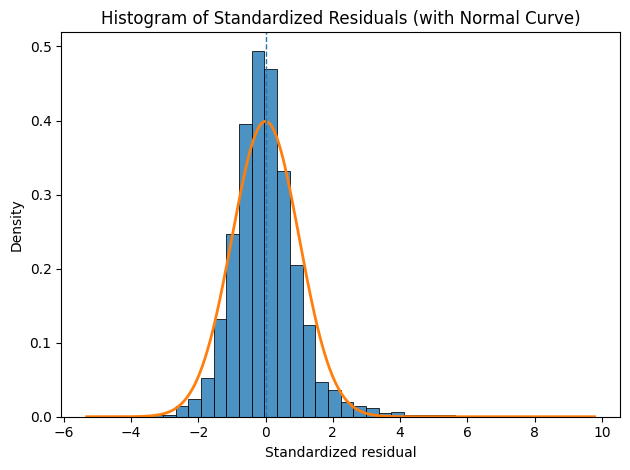

In [85]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1) Use standardized residuals (easier to read)
resid = model.resid
z = (resid - resid.mean()) / resid.std(ddof=1)

plt.figure()

# 2) Histogram (density=True for comparison with normal curve)
plt.hist(z, bins=40, density=True, alpha=0.8, edgecolor="black", linewidth=0.7)

# 3) Overlay Normal(0,1)
x = np.linspace(z.min(), z.max(), 400)
plt.plot(x, norm.pdf(x, 0, 1), linewidth=2)

# 4) Add reference line at 0
plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Histogram of Standardized Residuals (with Normal Curve)")
plt.xlabel("Standardized residual")
plt.ylabel("Density")
plt.tight_layout()
plt.show()



<Figure size 640x480 with 0 Axes>

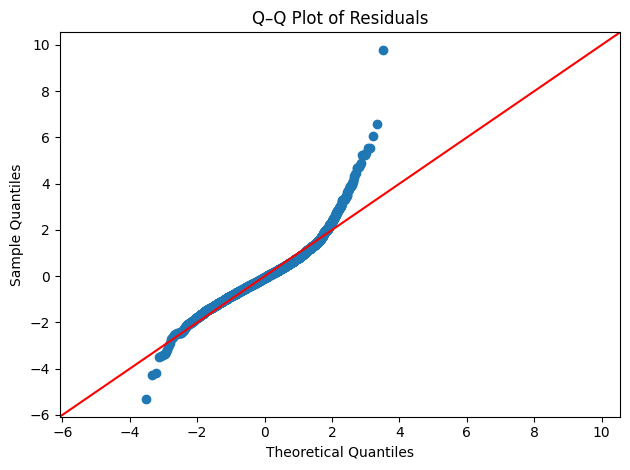

In [86]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.figure()
sm.qqplot(model.resid, line="45", fit=True)
plt.title("Q–Q Plot of Residuals")
plt.tight_layout()
plt.show()


# Does Non-Normality Matter for Regression?

## What Does Non-Normality Imply?

If residuals are not normally distributed:

- OLS coefficients are still **unbiased**.
- OLS coefficients are still **consistent**.
- R² remains valid.
- Predictions remain valid.

However:

- In **small samples**, t-tests and F-tests may not be exact.
- Confidence intervals may be slightly inaccurate.


# Should You Worry?

With a large sample size

Normality is **NOT very important**.


# Why?

Because of the **Central Limit Theorem (CLT)**.

The CLT states that:

\[
\hat{\beta} \text{ is approximately normally distributed for large } n
\]

even if the errors themselves are not normal.

This means:

- t-tests are approximately valid.
- p-values are reliable.
- Confidence intervals are valid.


# When DO We Care About Normality?

Normality matters when:

- The sample size is small (e.g., n < 30–50).
- There are extreme outliers.
- The distribution is highly skewed.
- You rely on exact small-sample inference.


# Practical Rule

| Sample Size | Should You Worry About Normality? |
|-------------|-----------------------------------|
| Small sample | Yes |
| Medium sample | Sometimes |
| Large sample (like 4682) | No |


# Final Takeaway

Even though the Jarque–Bera test rejects normality,  
with a large sample size the OLS inference remains valid due to the Central Limit Theorem.
